# Composer Identification using Neural Networks
AAI-511-02 Final Project\
By: Carlo Cassela, Jasmine Duong, Emmanuel Sadek



## Imports and Random Seeds




In [1]:
%%capture
!pip install pretty_midi tensorflow keras-tuner tensorboard

In [3]:
import hashlib, io, random, tempfile, zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pretty_midi
import tensorflow as tf
import os
import keras_tuner as kt
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (Attention, Bidirectional, Conv1D, Dense, Dropout,
                                     GlobalAveragePooling1D, GlobalMaxPooling1D, Input,
                                     LSTM, Masking, MaxPooling1D)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from google.colab import userdata

# Define random seeds for reproducibility
SEED = 21
tf.keras.utils.set_random_seed(SEED)
random.seed(SEED)

# Define target composers
composers = ["Bach", "Mozart", "Chopin", "Beethoven"]

## 1. Data Collection

### 1.1 Kaggle Dataset Download
Authenticates with the Kaggle API, downloads the midi-classic-music zip. Stores the raw zip bytes in memory. Need Kaggle credentials in Google Colab secrets

In [4]:
# API keys
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('kaggle_key')

In [5]:
# Authenticate
api = KaggleApi()
api.authenticate()

# Dataset Download into tmp directory/memory
with tempfile.TemporaryDirectory() as temp_folder:
    api.dataset_download_files("blanderbuss/midi-classic-music",
                               path=temp_folder, quiet=False, force=True)
    zip_bytes = list(Path(temp_folder).glob("*.zip"))[0].read_bytes()

Dataset URL: https://www.kaggle.com/datasets/blanderbuss/midi-classic-music


100%|██████████| 68.2M/68.2M [00:00<00:00, 90.6MB/s]

## 2. Data Preprocessing and EDA

### 2.1 Note Extraction From Midi File + Hashing

Opens the zip and parses every MIDI file for the composers. Extracts notes from MIDI file. Skips files that fail to load and stores a content hash for duplicate detection in later steps based upon notes.

In [6]:
# Create dictionary storage structure
midi_data = {}
for composer in composers:
    midi_data[composer] = {}

failed_files = 0
zip_file = zipfile.ZipFile(io.BytesIO(zip_bytes))

# Composer Parsing, Note Extraction, Hashing
for file_name in zip_file.namelist():
    parts = Path(file_name).parts
    if not file_name.lower().endswith((".mid", ".midi")):
        continue
    if len(parts) < 2 or parts[0] != "midiclassics":
        continue
    composer = parts[1]
    if composer not in composers:
        continue
    try:
        midi = pretty_midi.PrettyMIDI(io.BytesIO(zip_file.read(file_name)))
    except Exception:
        failed_files = failed_files + 1
        continue
    notes = []
    for instrument_number, instrument in enumerate(midi.instruments):
        for note in instrument.notes:
            notes.append({"pitch": int(note.pitch),
                          "start": float(note.start),
                          "end": float(note.end),
                          "velocity": int(note.velocity),
                          "duration": float(note.end - note.start),
                          "instrument": instrument_number})
    notes.sort(key=lambda note: note["start"])
    duration = float(midi.get_end_time())
    fingerprint = []
    for note in notes:
        fingerprint.append((note["pitch"] % 12, round(note["start"], 1), round(note["duration"], 1)))
    fingerprint.sort()
    midi_data[composer][Path(file_name).stem] = {
        "notes": notes,
        "duration": duration,
        "num_instruments": len(midi.instruments),
        "notes_per_second": len(notes) / duration if duration > 0 else 0,
        "content_hash": hashlib.md5(str(fingerprint).encode()).hexdigest(),
        "original_path": file_name,
    }

# File count reporting
zip_file.close()
print("Files that could not be read:", failed_files)
print("\nTotal Files Parsed:")
for composer in composers:
    print("  ", composer, "-->", len(midi_data[composer]), "files")

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Files that could not be read: 2

Total Files Parsed:
   Bach --> 1024 files
   Mozart --> 256 files
   Chopin --> 136 files
   Beethoven --> 212 files


### 2.2 Histogram Plotting Functions

In [7]:
# Helper method to create histograms
def draw_histogram(plot, values, label, color, title, whole_numbers=False):
    bins = range(1, max(values) + 2) if whole_numbers else 25
    average = np.mean(values)
    plot.hist(values, bins=bins, color=color, edgecolor="black", alpha=0.8)
    plot.axvline(average, color="red", linestyle="--", label="Mean: " + str(round(average, 1)))
    plot.set_title(title, fontsize=11)
    plot.set_xlabel(label)
    plot.set_ylabel("Count")
    plot.legend(fontsize=8)

# Plot number of instruments, note duration, notes per second
def plot_piece_histograms(data, title):
    metrics = ["num_instruments", "duration", "notes_per_second"]
    labels = ["Instruments", "Duration (s)", "Notes / Second"]
    colors = ["blue", "orange", "green"]
    figure, axes = plt.subplots(3, 4, figsize=(18, 12))
    figure.suptitle(title, fontsize=16)
    for column, composer in enumerate(composers):
        pieces = list(data[composer].values())
        for row in range(3):
            values = []
            for piece in pieces:
                values.append(piece[metrics[row]])
            draw_histogram(axes[row, column], values, labels[row], colors[row],
                           composer + " - " + labels[row],
                           whole_numbers=(metrics[row] == "num_instruments"))
    plt.tight_layout()
    plt.show()

### 2.3 Plot Distributions of Composer vs MIDI Info before Deduplication & Filter

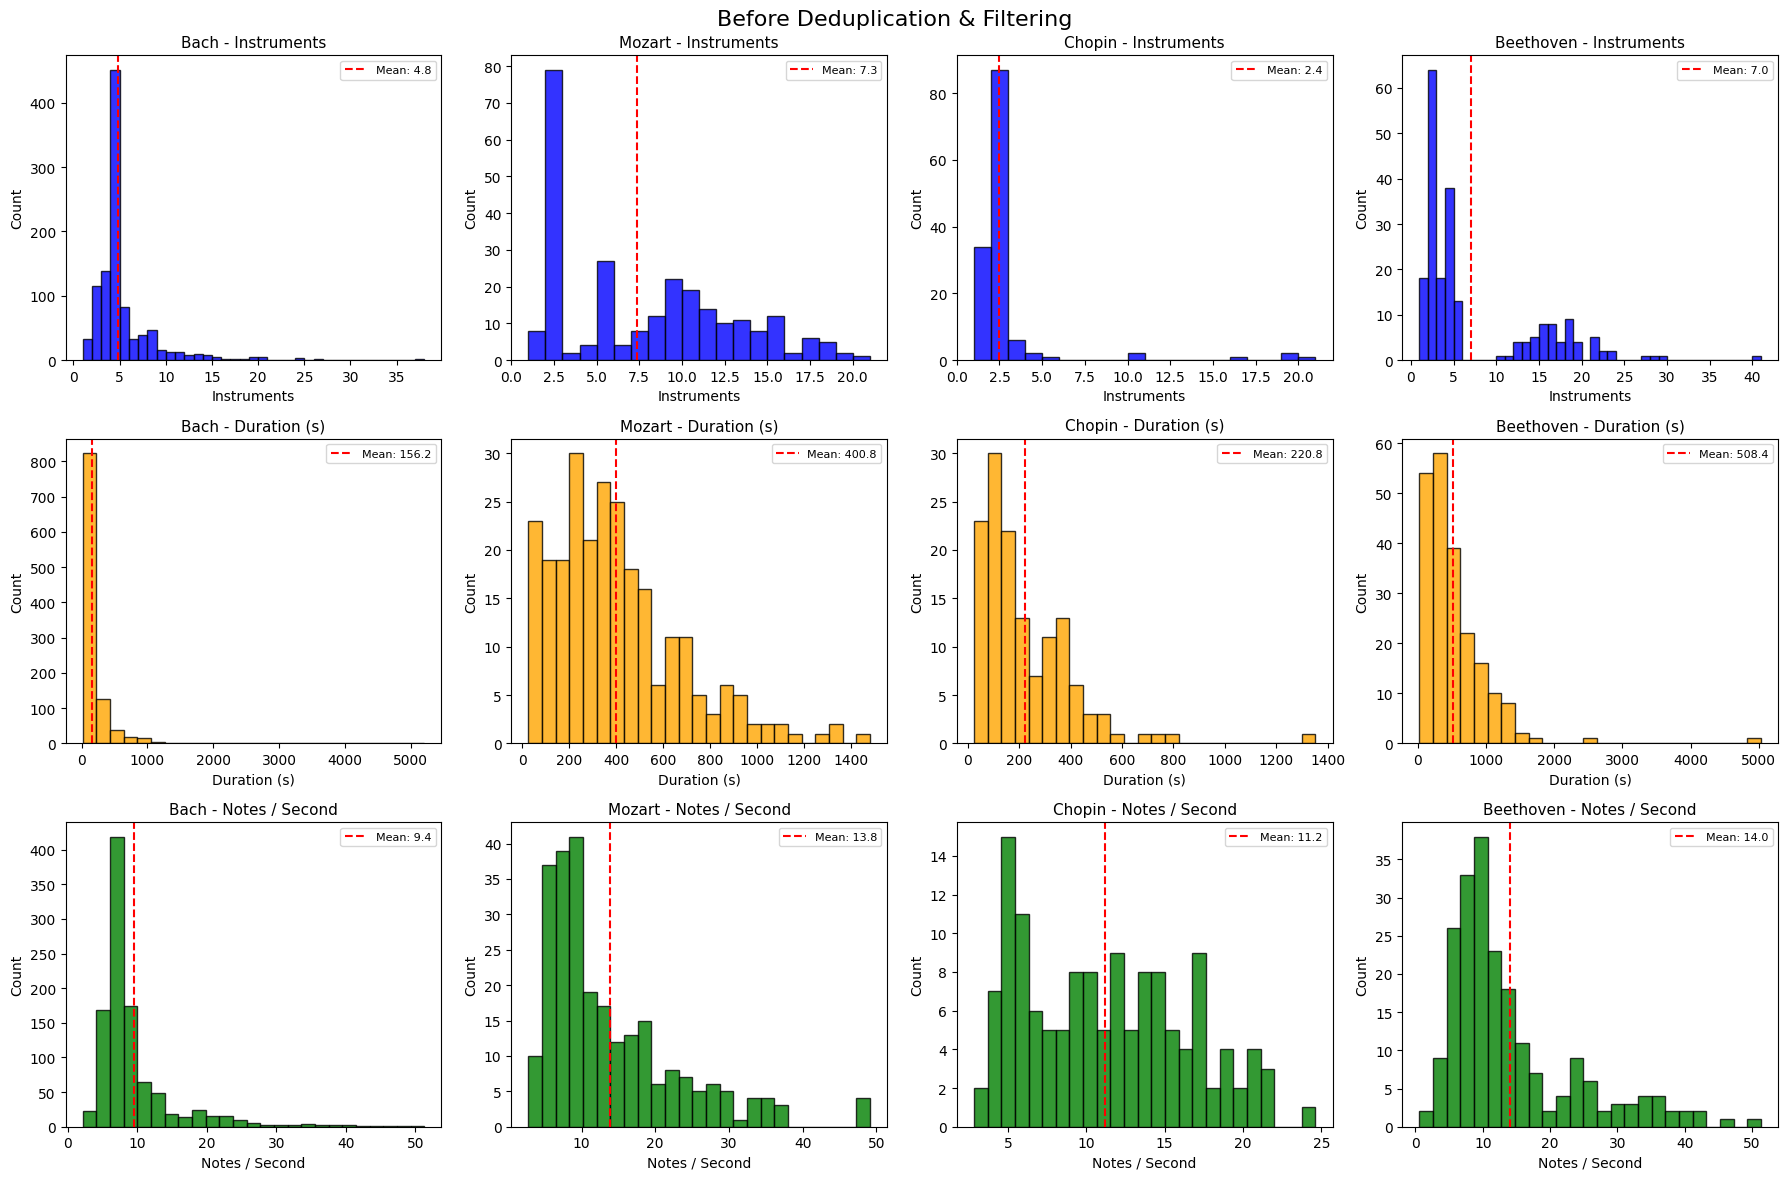

In [8]:
# Plot histograms
plot_piece_histograms(midi_data, "Before Deduplication & Filtering")

### 2.4 Remove duplicates

In [9]:
# Duplication removal based on hash values
print("Numbers Before/After Deduplication")
for composer in composers:
    seen_hashes = set()
    kept = {}
    for song_name, info in midi_data[composer].items():
        if info["content_hash"] not in seen_hashes:
            seen_hashes.add(info["content_hash"])
            kept[song_name] = info
    print("  ", composer, len(midi_data[composer]), "->", len(kept))
    midi_data[composer] = kept

Numbers Before/After Deduplication
   Bach 1024 -> 1011
   Mozart 256 -> 254
   Chopin 136 -> 132
   Beethoven 212 -> 204


### 2.5 Keep only pieces of a reasonable length and remove outliers
Based off of distributions outliers exist in:    
- Number of instruments: Capped at 20 instruments - Beethoven has numerous works with greater than 20 instruments    
- Duration: Capped at 1000 seconds - multiple outliers, does not remove much data    

Remove songs less than 60 seconds to accommodate sliding window





In [10]:
MIN_DURATION, MAX_DURATION = 60, 1000
MIN_INSTRUMENTS, MAX_INSTRUMENTS = 1, 20

print("Numbers Before/After Filtering")
midi_clean = {}
for composer in composers:
    kept = {}
    for song_name, info in midi_data[composer].items():
        good_length = MIN_DURATION <= info["duration"] <= MAX_DURATION
        good_size = MIN_INSTRUMENTS <= info["num_instruments"] <= MAX_INSTRUMENTS
        if good_length and good_size:
            kept[song_name] = info
    midi_clean[composer] = kept
    print("  ", composer, len(midi_data[composer]), "->", len(kept))

Numbers Before/After Filtering
   Bach 1011 -> 582
   Mozart 254 -> 232
   Chopin 132 -> 115
   Beethoven 204 -> 156


### 2.6 Look at clean data
Data looks more evenly distributed accross composers which results in a more fair comparison

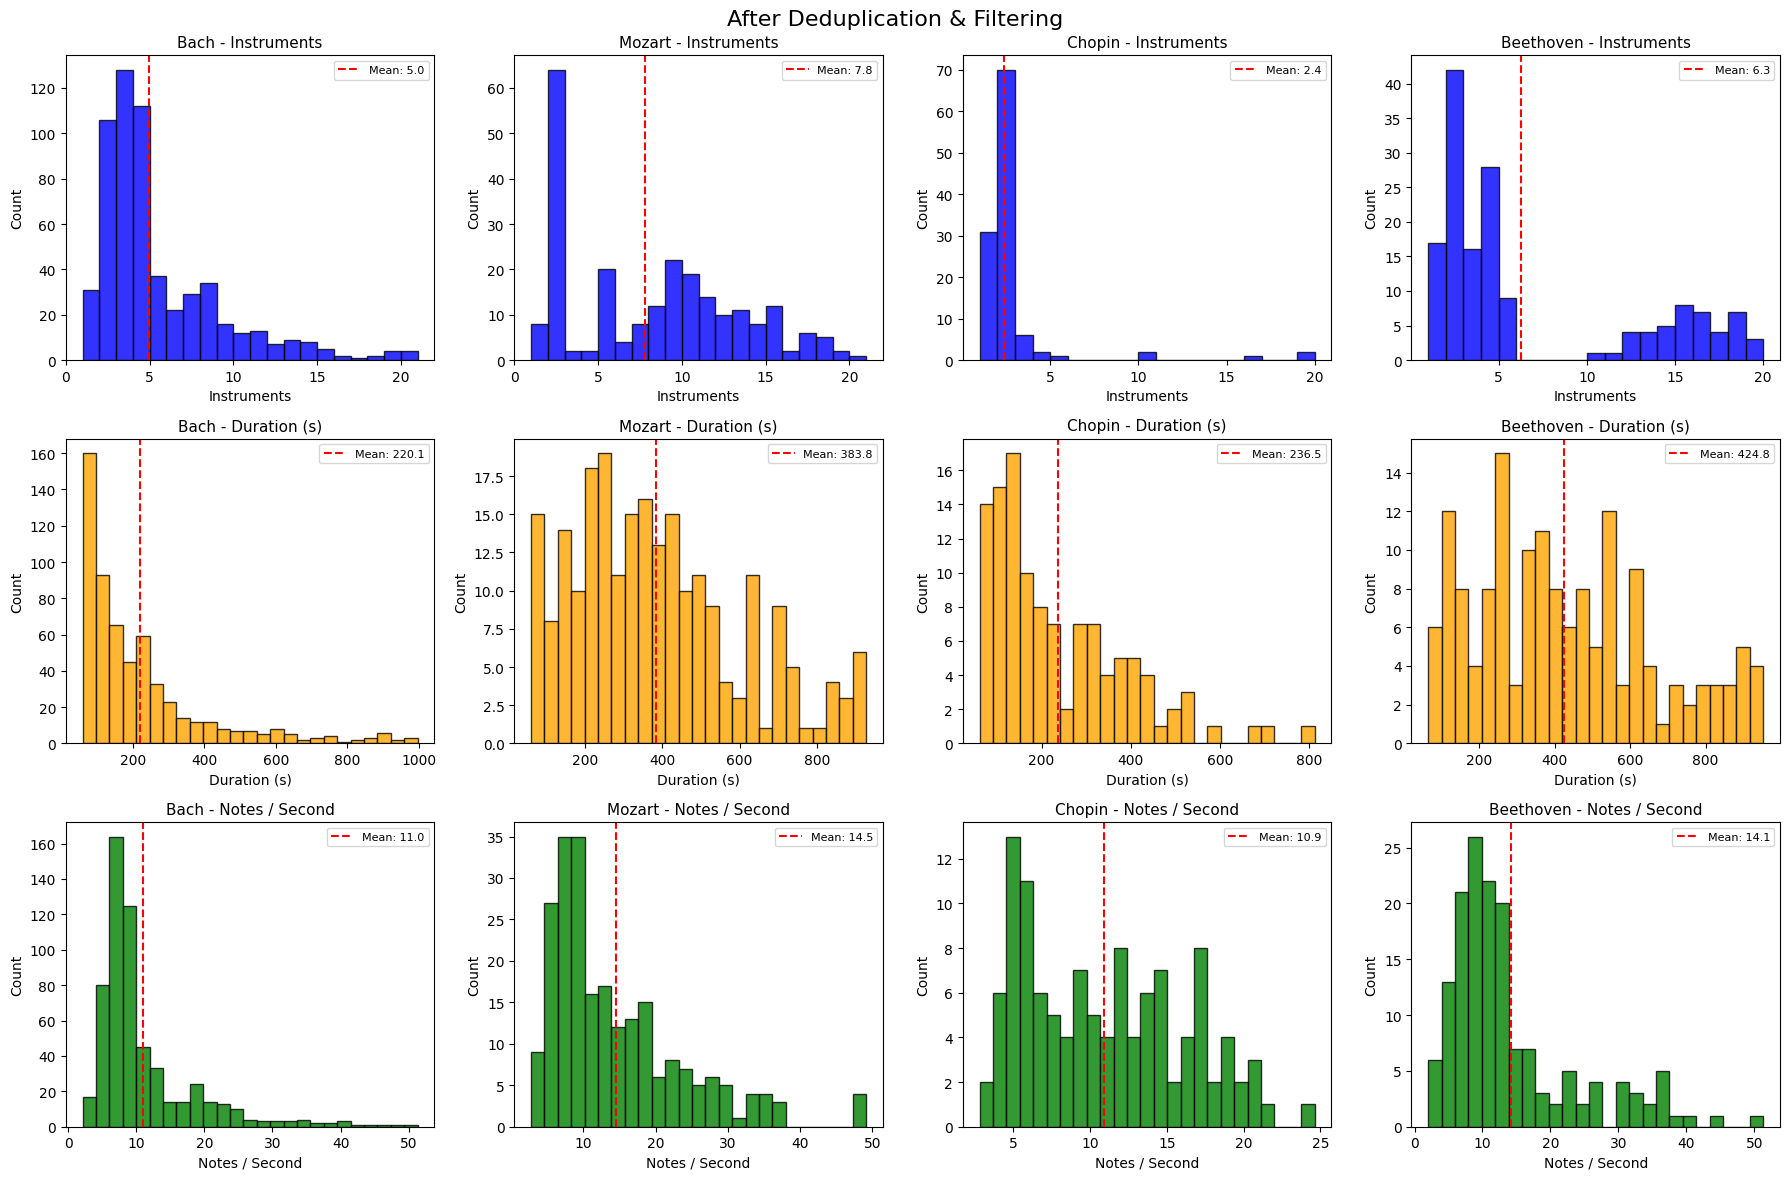

In [11]:
plot_piece_histograms(midi_clean, "After Deduplication & Filtering")

## 3. Feature Engineering
Converts each piece’s notes into a DataFrame that includes additional calculated features such as rolling pitch statistics, pitch class, interval, inter-onset interval and simultaneous note count.

In [12]:
# Feature calculation
for composer in composers:
    for song_name, info in midi_clean[composer].items():
        notes_df = pd.DataFrame(info["notes"]).sort_values("start").reset_index(drop=True)
        notes_df = notes_df.set_index(pd.to_timedelta(notes_df["start"], unit="s"), drop=False)
        rolling_2s = notes_df["pitch"].rolling("2s", closed="both")
        rolling_5s = notes_df["pitch"].rolling("5s", closed="both")
        notes_df["pitch_dev_2s"] = notes_df["pitch"] - rolling_2s.mean()
        notes_df["pitch_dev_5s"] = notes_df["pitch"] - rolling_5s.mean()
        notes_df["pitch_range_2s"] = rolling_2s.max() - rolling_2s.min()
        notes_df["duration"] = notes_df["end"] - notes_df["start"]
        notes_df = notes_df.reset_index(drop=True)
        notes_df["pitch_class"] = notes_df["pitch"] % 12
        notes_df["interval"] = notes_df["pitch"].diff().fillna(0)
        notes_df["ioi"] = notes_df["start"].diff().fillna(0)
        start_times = notes_df["start"].values
        sorted_starts = np.sort(start_times)
        sorted_ends = np.sort(notes_df["end"].values)
        already_started = np.searchsorted(sorted_starts, start_times, side="right")
        already_finished = np.searchsorted(sorted_ends, start_times, side="right")
        notes_df["active_notes"] = already_started - already_finished
        info["notes"] = notes_df.fillna(0)

## 4. Song Snippet Window
- Slides a 30-second window with a 20 second stride across every piece and keeps only windows that contain at least 30 notes.
- Stores each snippet with its composer and song name.    
- Songs names are stored to make sure individual songs are not split across  test/train/val datasets. (i.e. test/train/val should only contain songs unique to the dataset)
- Snippets should contain at least 1 note per second - anything less is mostly blank or potentially missing data.

In [13]:
# Features
features = ["pitch", "pitch_class", "interval", "pitch_dev_2s", "pitch_dev_5s",
            "pitch_range_2s", "duration", "ioi", "active_notes"]

# Window definition
SNIPPET_DURATION = 30.0 # Seconds
STRIDE = 20.0 # Seconds
MIN_NOTES_PER_SNIPPET = 30 # 1 Note per second

# Apply sliding window
samples = []
for composer in composers:
    for song_name, info in midi_clean[composer].items():
        notes_df = info["notes"]
        for snippet_number, window_start in enumerate(np.arange(0, info["duration"], STRIDE)):
            after_start = notes_df["start"] >= window_start
            before_end = notes_df["start"] < window_start + SNIPPET_DURATION
            snippet = notes_df[after_start & before_end]
            if len(snippet) < MIN_NOTES_PER_SNIPPET:
                continue
            samples.append({"composer": composer,
                            "song_name": song_name,
                            "snippet_index": snippet_number,
                            "n_notes": len(snippet),
                            "n_unique_instruments": snippet["instrument"].nunique(),
                            "original_duration": info["duration"],
                            "notes": snippet[features].reset_index(drop=True)})

print("Total snippets:", len(samples))

Total snippets: 15649


## 5. Split into (Train/Validation/Test) by Song, Not Snippet
Collects unique songs, does a stratified 70/15/15 split by composer, and assigns every snippet to the split of its parent song.



In [14]:
# Collect unique songs
all_songs = sorted(set(s["composer"] + "/" + s["song_name"] for s in samples))

# Stratify by composer so every split gets a similar mix.
song_composers = []
for song_id in all_songs:
    song_composers.append(song_id.split("/")[0])

train_val_songs, test_songs = train_test_split(all_songs, test_size=0.15,
                                               random_state=SEED, stratify=song_composers)

train_val_composers = []
for song_id in train_val_songs:
    train_val_composers.append(song_id.split("/")[0])

# 0.1765 of the remaining 85% works out to roughly 15% of everything.
train_songs, val_songs = train_test_split(train_val_songs, test_size=0.1765,
                                          random_state=SEED, stratify=train_val_composers)

# Remember which split each song belongs to, then send its snippets there.
song_split = {}
for song_id in train_songs:
    song_split[song_id] = "train"
for song_id in val_songs:
    song_split[song_id] = "val"
for song_id in test_songs:
    song_split[song_id] = "test"

splits = {"train": [], "val": [], "test": []}
for sample in samples:
    splits[song_split[sample["composer"] + "/" + sample["song_name"]]].append(sample)

print("Songs --> train:", len(train_songs), "val:", len(val_songs), "test:", len(test_songs))

Songs --> train: 759 val: 163 test: 163


### 5.1 Balance the Composers
Downsamples each split so every composer has the same number of snippets (the size of the smallest class).

In [15]:
for split_name in ["train", "val", "test"]:
    by_composer = {}
    for composer in composers:
        by_composer[composer] = []
    for sample in splits[split_name]:
        by_composer[sample["composer"]].append(sample)
    # The composer with the fewest snippets sets the limit.
    smallest = min(len(by_composer[c]) for c in composers)
    balanced = []
    for composer in composers:
        balanced.extend(random.sample(by_composer[composer], smallest))
    random.shuffle(balanced)
    splits[split_name] = balanced
    print(split_name, "->", len(balanced), "snippets,", smallest, "per composer")

train -> 4088 snippets, 1022 per composer
val -> 612 snippets, 153 per composer
test -> 732 snippets, 183 per composer


### 5.2 Histograms of the snippets per composer

Plots note-count and unique-instrument distributions. This is the actual data that will be fed into the model

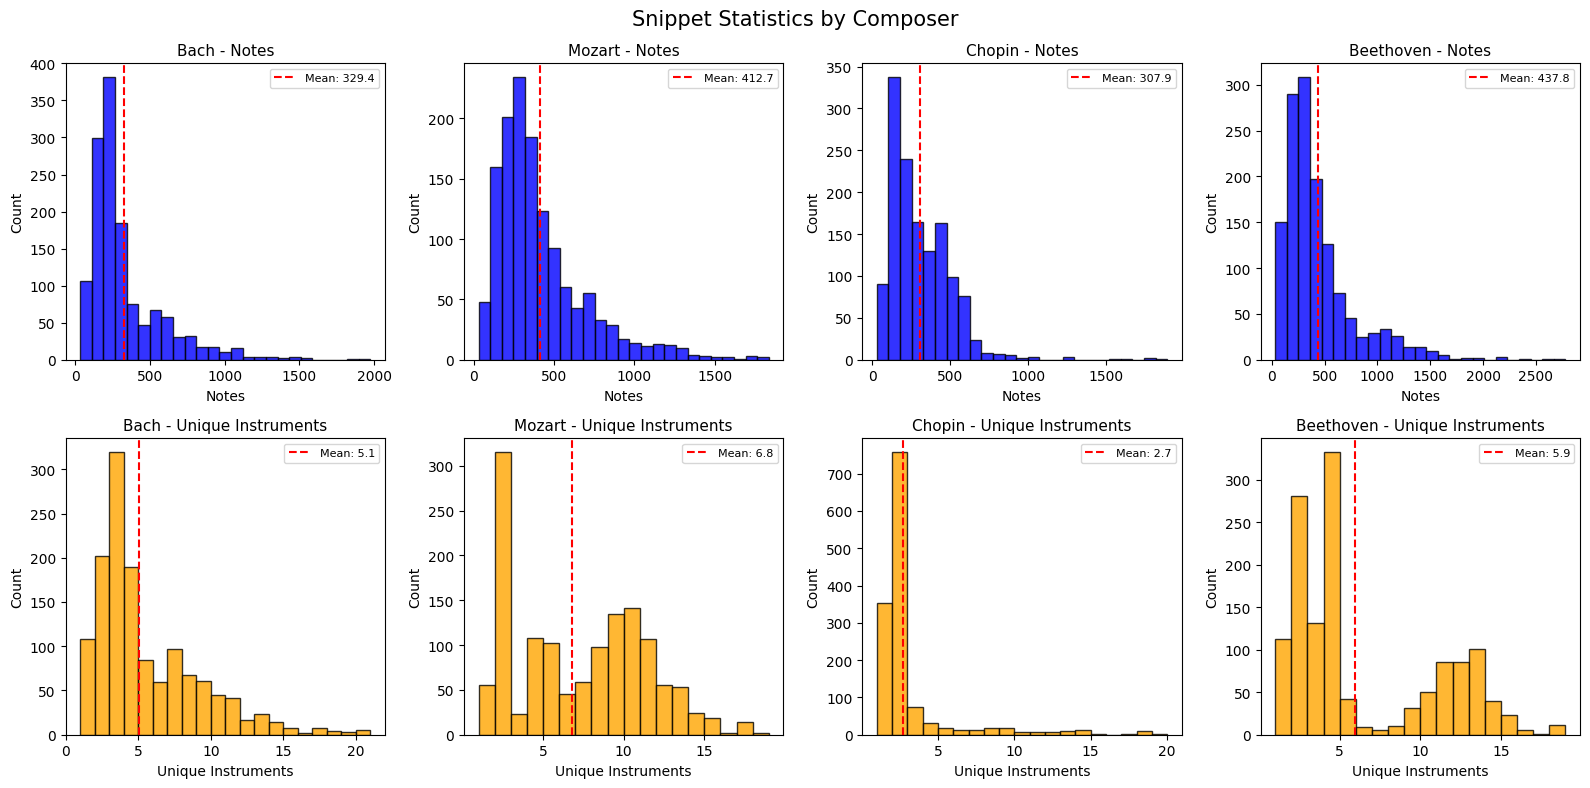

In [16]:
all_snippets = splits["train"] + splits["val"] + splits["test"]
metrics = ["n_notes", "n_unique_instruments"]
labels = ["Notes", "Unique Instruments"]
colors = ["blue", "orange"]

figure, axes = plt.subplots(2, 4, figsize=(16, 8))
figure.suptitle("Snippet Statistics by Composer", fontsize=15)
for column, composer in enumerate(composers):
    for row in range(2):
        values = []
        for snippet in all_snippets:
            if snippet["composer"] == composer:
                values.append(snippet[metrics[row]])
        draw_histogram(axes[row, column], values, labels[row], colors[row],
                       composer + " - " + labels[row], whole_numbers=(row == 1))
plt.tight_layout()
plt.show()

### 5.3 Decide MAX_LENGTH
- Sets MAX_LENGTH to the nearest common size near the 75th percentile of training snippet lengths. Creates the composer-to-label dictionary.     
- This step is done to ensure certain composers are not unfairly zero-padded or truncated more than others - Calculated off training data only

In [17]:
p75 = np.percentile([s["n_notes"] for s in splits["train"]], 75)
MAX_LENGTH = min([128, 256, 384, 512, 768, 1024], key=lambda x: abs(x - p75))
print(f"MAX_LENGTH = {MAX_LENGTH}")

composer_to_label = {"Bach": 0, "Mozart": 1, "Chopin": 2, "Beethoven": 3}

MAX_LENGTH = 512


### 5.4 Build the X and y arrays    
Pads or truncates every snippet to exactly MAX_LENGTH notes and converts the three splits into NumPy arrays X and y.

In [18]:
# Function to pad/truncate based on MAX_LENGTH calculated earlier
def pad_or_truncate(notes_df, max_length=MAX_LENGTH):
    """Make every snippet exactly max_length rows long."""
    data = notes_df.values.astype(np.float32)
    if len(data) > max_length:
        return data[:max_length]
    padded = np.zeros((max_length, data.shape[1]), dtype=np.float32)
    padded[:len(data)] = data
    return padded

# Build X and y
def build_arrays(split_name):
    """Turn a list of snippets into the X and y arrays Keras wants."""
    X_list, y_list = [], []
    for sample in splits[split_name]:
        X_list.append(pad_or_truncate(sample["notes"]))
        y_list.append(composer_to_label[sample["composer"]])
    return np.array(X_list), np.array(y_list)

X_train, y_train = build_arrays("train")
X_val, y_val = build_arrays("val")
X_test, y_test = build_arrays("test")


### 5.5 Scale the features
- Fits a StandardScaler on the real (non-padded) training notes only.
- Applies scale to all three splits while leaving the zero-padding untouched.
- One-hot encodes the labels.

In [19]:
# Flatten all training sequences so we can fit the scaler on every real note at once
n_features = len(features)
all_train_rows = X_train.reshape(-1, n_features)

# Identify rows that are actual notes (not the zero-padding)
is_real_note = ~np.all(all_train_rows == 0, axis=1)

# Fit the scaler only on real notes from the training set (not the zero-padding)
scaler = StandardScaler()
scaler.fit(all_train_rows[is_real_note])

def scale_features(X):
    X_scaled = X.copy()
    for i in range(len(X_scaled)):
        real_rows = ~np.all(X_scaled[i] == 0, axis=1)
        X_scaled[i][real_rows] = scaler.transform(X_scaled[i][real_rows])
    return X_scaled

# Apply the same scaling to all three splits
X_train = scale_features(X_train)
X_val = scale_features(X_val)
X_test = scale_features(X_test)

# One-hot encoder
y_train_cat = to_categorical(y_train, 4)
y_val_cat = to_categorical(y_val, 4)
y_test_cat = to_categorical(y_test, 4)

# Finalized test/train/val split
print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (4088, 512, 9)  Val: (612, 512, 9)  Test: (732, 512, 9)


## 6. Model Building

### 6.1 Functions for Models
Creates EarlyStopping and ReduceLROnPlateau callbacks and a function that plots train/val loss and accuracy curves.

In [20]:
# EarlyStopping and Reduce LR on Plateau
def make_callbacks():
    early_stopping = EarlyStopping(monitor="val_accuracy", patience=6,
                                   restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor="val_accuracy", factor=0.5,
                                  patience=3, min_lr=1e-6, verbose=1)
    return [early_stopping, reduce_lr]

# Function to plot loss and accuracy per epoch
def plot_training(history, model_name):
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    for i, metric in enumerate(["loss", "accuracy"]):
        axes[i].plot(history.history[metric], label="train")
        axes[i].plot(history.history["val_" + metric], label="val")
        axes[i].set_title(model_name + " - " + metric)
        axes[i].set_xlabel("Epoch")
        axes[i].legend()
    plt.tight_layout()
    plt.show()

### 6.2 Bidirectional LSTM Model with Attention
Two layer bidirectional LSTM model with self attention, global average pooling, 4 class softmax function, Adam optimizer, categorical cross-entropy loss.

In [21]:
# Apply Seed for consistent results
tf.keras.utils.set_random_seed(SEED)

# LSTM model
inputs = Input(shape=(MAX_LENGTH, n_features))
x = Masking(mask_value=0.0)(inputs)

# Layer 1
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.5)(x)

# Layer 2
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.5)(x)

# Self attention
x = Attention()([x, x])

x = GlobalAveragePooling1D()(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(4, activation="softmax")(x)

lstm = Model(inputs, outputs)

lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="categorical_crossentropy", metrics=["accuracy"])
lstm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 512, 9)    │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 512, 9)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 512)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 512, 128)  │     37,888 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512, 128)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 512, 128)  │     98,816 │ dropout[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512, 128)  │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 512, 128)  │          0 │ dropout_1[0][0],  │
│ (Attention)         │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convert_to_tensor   │ (None, 512)       │          0 │ any[0][0]         │
│ (ConvertToTensor)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0],  │
│ (GlobalAveragePool… │                   │            │ convert_to_tenso… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        132 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 140,964 (550.64 KB)

 Trainable params: 140,964 (550.64 KB)

 Non-trainable params: 0 (0.00 B)

### 6.3 Train the LSTM

In [22]:
# Train LSTM for 40 epochs and batch size 64
lstm_history = lstm.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
                        epochs=40, batch_size=64, callbacks=make_callbacks(), verbose=1)

Epoch 1/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.4335 - loss: 1.2296 - val_accuracy: 0.4199 - val_loss: 1.2528 - learning_rate: 0.0010
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.5098 - loss: 1.1256 - val_accuracy: 0.4820 - val_loss: 1.1919 - learning_rate: 0.0010
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.5585 - loss: 1.0584 - val_accuracy: 0.4984 - val_loss: 1.1129 - learning_rate: 0.0010
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.5886 - loss: 0.9913 - val_accuracy: 0.5343 - val_loss: 1.0835 - learning_rate: 0.0010
Epoch 5/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.6255 - loss: 0.9231 - val_accuracy: 0.5621 - val_loss: 1.0190 - learning_rate: 0.0010
Epoch 6/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.6614 - loss: 0.8516 - val_accuracy: 0.5850 - val_loss: 0.9671 - learning_rate: 0.0010
Epoch 7/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.6830 - loss: 0.8202 - val_a

### 6.4 Evaluate the LSTM

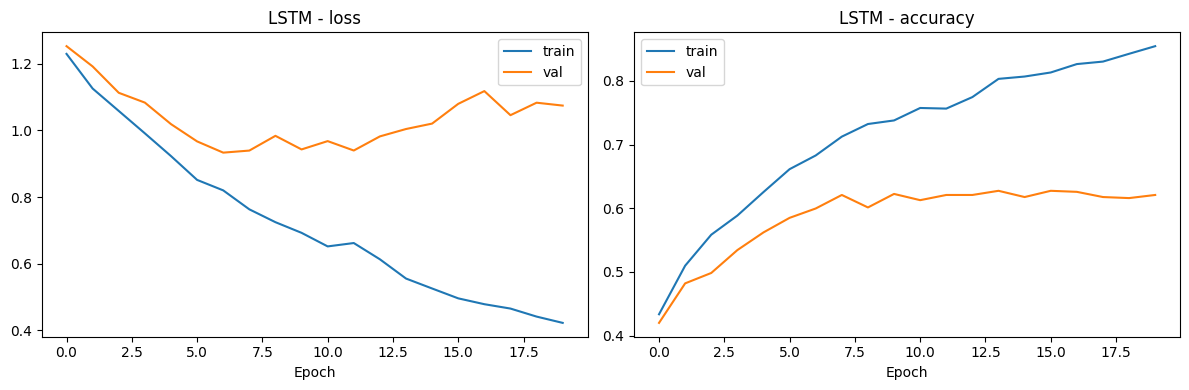

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
LSTM test accuracy: 0.6885
              precision    recall  f1-score   support

        Bach     0.6698    0.7869    0.7236       183
      Mozart     0.6647    0.6175    0.6402       183
      Chopin     0.7907    0.7432    0.7662       183
   Beethoven     0.6343    0.6066    0.6201       183

    accuracy                         0.6885       732
   macro avg     0.6899    0.6885    0.6875       732
weighted avg     0.6899    0.6885    0.6875       732



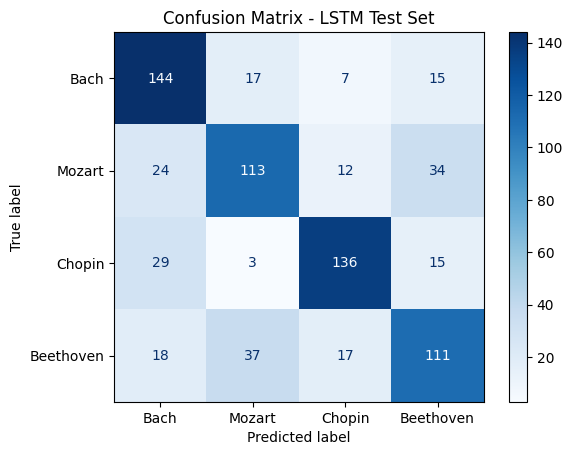

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
LSTM ROC AUC Score: 0.8837


In [23]:
# Training Curve
plot_training(lstm_history, "LSTM")
y_pred_lstm = np.argmax(lstm.predict(X_test), axis=1)
lstm_accuracy = lstm.evaluate(X_test, y_test_cat, verbose=0)[1]

# Test Accuracy + classification report
print("LSTM test accuracy:", round(lstm_accuracy, 4))
print(classification_report(y_test, y_pred_lstm, target_names=composers, digits=4))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lstm),
                       display_labels=composers).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - LSTM Test Set")
plt.show()

# ROC AUC
print("LSTM ROC AUC Score:", round(roc_auc_score(y_test_cat, lstm.predict(X_test), multi_class="ovr"), 4))

### 6.5 1D CNN Model  
1D CNN model with three blocks using activation function ReLU, global max pooling, 4 class softmax function, Adam optimizer, and categorical cross-entropy loss.

In [24]:
# Apply seed for consistent results
tf.keras.utils.set_random_seed(SEED)

# 1D CNN model
inputs = Input(shape=(MAX_LENGTH, n_features))

# Block 1
x = Conv1D(64, 5, padding="same", activation="relu")(inputs)
x = MaxPooling1D(2)(x)
x = Dropout(0.25)(x)

# Block 2
x = Conv1D(128, 5, padding="same", activation="relu")(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.25)(x)

# Block 3
x = Conv1D(144, 5, padding="same", activation="relu")(x)
x = GlobalMaxPooling1D()(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.4)(x)

outputs = Dense(4, activation="softmax")(x)

cnn = Model(inputs, outputs)
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss="categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

print("LSTM parameters:", lstm.count_params())
print("CNN parameters: ", cnn.count_params())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 512, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 128, 144)       │        92,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 144)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,108 (551.20 KB)

 Trainable params: 141,108 (551.20 KB)

 Non-trainable params: 0 (0.00 B)

LSTM parameters: 140964
CNN parameters:  141108


### 6.6 Train the CNN

In [25]:
# Train CNN model with 40 epochs, 64 batch size
cnn_history = cnn.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
                      epochs=40, batch_size=64, callbacks=make_callbacks(), verbose=1)

Epoch 1/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 192ms/step - accuracy: 0.3170 - loss: 1.3720 - val_accuracy: 0.3660 - val_loss: 1.3000 - learning_rate: 0.0010
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4051 - loss: 1.2637 - val_accuracy: 0.3954 - val_loss: 1.2396 - learning_rate: 0.0010
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4310 - loss: 1.2238 - val_accuracy: 0.4281 - val_loss: 1.2105 - learning_rate: 0.0010
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4626 - loss: 1.1898 - val_accuracy: 0.4542 - val_loss: 1.2033 - learning_rate: 0.0010
Epoch 5/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5015 - loss: 1.1421 - val_accuracy: 0.4788 - val_loss: 1.1248 - learning_rate: 0.0010
Epoch 6/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5227 - loss: 1.1039 - val_accuracy: 0.4984 - val_loss: 1.1045 - learning_rate: 0.0010
Epoch 7/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5558 - loss: 1.0453 - val_a

### 6.7 Evaluate the CNN

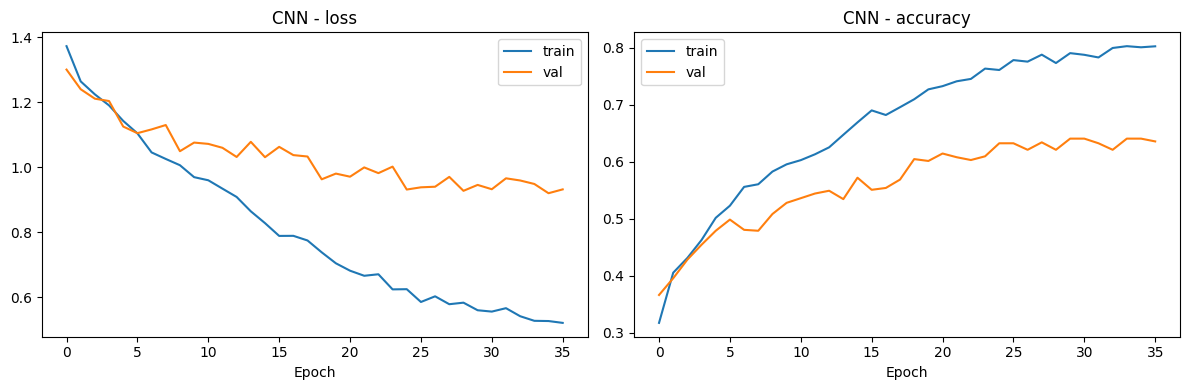

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
CNN test accuracy: 0.6626
              precision    recall  f1-score   support

        Bach     0.6842    0.7814    0.7296       183
      Mozart     0.5708    0.7049    0.6308       183
      Chopin     0.8037    0.7158    0.7572       183
   Beethoven     0.6119    0.4481    0.5174       183

    accuracy                         0.6626       732
   macro avg     0.6677    0.6626    0.6587       732
weighted avg     0.6677    0.6626    0.6587       732



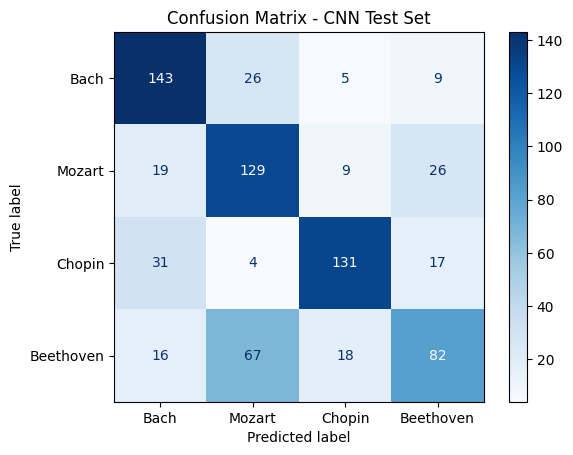

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
CNN ROC AUC Score: 0.8718


In [26]:
# Training curve
plot_training(cnn_history, "CNN")
y_pred_cnn = np.argmax(cnn.predict(X_test), axis=1)
cnn_accuracy = cnn.evaluate(X_test, y_test_cat, verbose=0)[1]

# Test accuracy + classification report
print("CNN test accuracy:", round(cnn_accuracy, 4))
print(classification_report(y_test, y_pred_cnn, target_names=composers, digits=4))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_cnn),
                       display_labels=composers).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - CNN Test Set")
plt.show()

# ROC AUC
print("CNN ROC AUC Score:", round(roc_auc_score(y_test_cat, cnn.predict(X_test), multi_class="ovr"), 4))

### 6.8 Compare the Two Models

In [27]:
# Compare LSTM and CNN models
print("LSTM:", lstm.count_params(), "parameters, test accuracy", round(lstm_accuracy, 4))
print("CNN: ", cnn.count_params(), "parameters, test accuracy", round(cnn_accuracy, 4))
print("Random guessing would be about 0.25")

LSTM: 140964 parameters, test accuracy 0.6885
CNN:  141108 parameters, test accuracy 0.6626
Random guessing would be about 0.25


In [28]:
# Compare classification reports
print(f"LSTM: {classification_report(y_test, y_pred_lstm, target_names=composers, digits=4)}")
print(f"CNN: {classification_report(y_test, y_pred_cnn, target_names=composers, digits=4)}")

LSTM:               precision    recall  f1-score   support

        Bach     0.6698    0.7869    0.7236       183
      Mozart     0.6647    0.6175    0.6402       183
      Chopin     0.7907    0.7432    0.7662       183
   Beethoven     0.6343    0.6066    0.6201       183

    accuracy                         0.6885       732
   macro avg     0.6899    0.6885    0.6875       732
weighted avg     0.6899    0.6885    0.6875       732

CNN:               precision    recall  f1-score   support

        Bach     0.6842    0.7814    0.7296       183
      Mozart     0.5708    0.7049    0.6308       183
      Chopin     0.8037    0.7158    0.7572       183
   Beethoven     0.6119    0.4481    0.5174       183

    accuracy                         0.6626       732
   macro avg     0.6677    0.6626    0.6587       732
weighted avg     0.6677    0.6626    0.6587       732



## 7. Hyperparameter Tuning
* Tune hyperparameters using Keras-tuner

### 7.1 LSTM Hyperparameter Tuning
* Tune for LSTM units, dropout value, activation function, dense neuron value, and initial learning rate using RandomSearch
* Train new model based off of best hyperparameters

In [29]:
tf.keras.utils.set_random_seed(SEED)

def build_tuning_lstm(hp):
  tf.keras.utils.set_random_seed(SEED)
  inputs = Input(shape=(MAX_LENGTH, n_features))

  x = Masking(mask_value=0.0)(inputs)

  # Hyperparameter choices
  lstm_units = hp.Choice('lstm_units', values = [64, 128, 256])
  dropout_val = hp.Choice('dropout', values = [0.2, 0.4, 0.5])
  activation_choice = hp.Choice('activation', values = ['relu', 'leaky_relu'])

  # Define model with choice values
  x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
  x = Dropout(dropout_val)(x)

  x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
  x = Dropout(dropout_val)(x)

  x = Attention()([x, x])
  x = GlobalAveragePooling1D()(x)

  # Tune dense neuron value
  dense_neurons = hp.Choice('dense_neurons', values = [32, 64, 128])
  x = Dense(dense_neurons, activation=activation_choice)(x)
  x = Dropout(dropout_val)(x)

  # Output
  outputs = Dense(4, activation="softmax")(x)

  model = Model(inputs=inputs, outputs=outputs)

  # Tune learning rate
  lr = hp.Choice('learning_rate', values = [1e-2, 5e-4, 1e-4])

  # Compile model with learning rate choices
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                loss="categorical_crossentropy", metrics=["accuracy"])

  return model

In [30]:
tf.keras.utils.set_random_seed(SEED)

# Define tuner
lstm_tuner = kt.RandomSearch(
    build_tuning_lstm,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=3,
    directory='tuning_results',
    project_name='tuning_lstm'
)

# Start tuning
lstm_tuner.search(
    X_train, y_train_cat,
    epochs = 40,
    batch_size = 64,
    validation_data = (X_val, y_val_cat),
    callbacks = make_callbacks()
)

Trial 5 Complete [00h 05m 05s]
val_accuracy: 0.25

Best val_accuracy So Far: 0.6775599320729574
Total elapsed time: 00h 50m 38s


In [31]:
# Look at best hyperparameters
best_lstm_param = lstm_tuner.get_best_hyperparameters()[0].values
best_lstm_param

{'lstm_units': 64,
 'dropout': 0.5,
 'activation': 'relu',
 'dense_neurons': 64,
 'learning_rate': 0.01}

In [32]:
tf.keras.utils.set_random_seed(SEED)

# Tune new model with best hyperparameters
best_hp = lstm_tuner.get_best_hyperparameters(num_trials=1)[0]
best_lstm_model = build_tuning_lstm(best_hp)
best_lstm_model.fit(X_train, y_train_cat, epochs=40, batch_size=64, validation_data=(X_val, y_val_cat), callbacks=make_callbacks())

Epoch 1/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.4379 - loss: 1.2361 - val_accuracy: 0.4346 - val_loss: 1.3042 - learning_rate: 0.0100
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.5428 - loss: 1.0824 - val_accuracy: 0.4886 - val_loss: 1.1660 - learning_rate: 0.0100
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.6096 - loss: 0.9596 - val_accuracy: 0.5719 - val_loss: 1.0217 - learning_rate: 0.0100
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.6512 - loss: 0.8827 - val_accuracy: 0.5343 - val_loss: 1.0504 - learning_rate: 0.0100
Epoch 5/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.6681 - loss: 0.8313 - val_accuracy: 0.5588 - val_loss: 0.9875 - learning_rate: 0.0100
Epoch 6/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.6862 - loss: 0.7829 - val_accuracy: 0.6062 - val_loss: 0.9709 - learning_rate: 0.0100
Epoch 7/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.7214 - loss: 0.7157 - v

In [33]:
# Look at classification report for tuned model
tuned_preds_lstm = np.argmax(best_lstm_model.predict(X_test), axis=1)
print(classification_report(y_test, tuned_preds_lstm, target_names=composers, digits=4))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
              precision    recall  f1-score   support

        Bach     0.8742    0.7213    0.7904       183
      Mozart     0.5792    0.6995    0.6337       183
      Chopin     0.7600    0.8306    0.7937       183
   Beethoven     0.6188    0.5410    0.5773       183

    accuracy                         0.6981       732
   macro avg     0.7080    0.6981    0.6988       732
weighted avg     0.7080    0.6981    0.6988       732



### 7.2 LSTM Model Comparison
Compare results of tuned model versus untuned

In [34]:
# Compare classification reports for tuned vs untuned
print(f"Untuned LSTM: {classification_report(y_test, y_pred_lstm, target_names=composers, digits=4)}")
print(f"Tuned LSTM: {classification_report(y_test, tuned_preds_lstm, target_names=composers, digits=4)}")

Untuned LSTM:               precision    recall  f1-score   support

        Bach     0.6698    0.7869    0.7236       183
      Mozart     0.6647    0.6175    0.6402       183
      Chopin     0.7907    0.7432    0.7662       183
   Beethoven     0.6343    0.6066    0.6201       183

    accuracy                         0.6885       732
   macro avg     0.6899    0.6885    0.6875       732
weighted avg     0.6899    0.6885    0.6875       732

Tuned LSTM:               precision    recall  f1-score   support

        Bach     0.8742    0.7213    0.7904       183
      Mozart     0.5792    0.6995    0.6337       183
      Chopin     0.7600    0.8306    0.7937       183
   Beethoven     0.6188    0.5410    0.5773       183

    accuracy                         0.6981       732
   macro avg     0.7080    0.6981    0.6988       732
weighted avg     0.7080    0.6981    0.6988       732



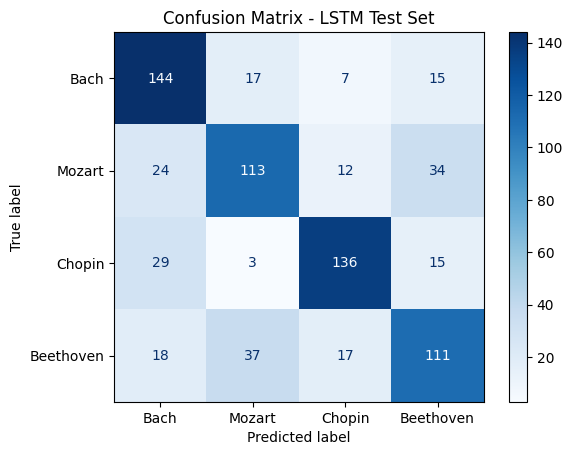

In [35]:
# Compare confusion matrix for untuned
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lstm),
                       display_labels=composers).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - LSTM Test Set")
plt.show()

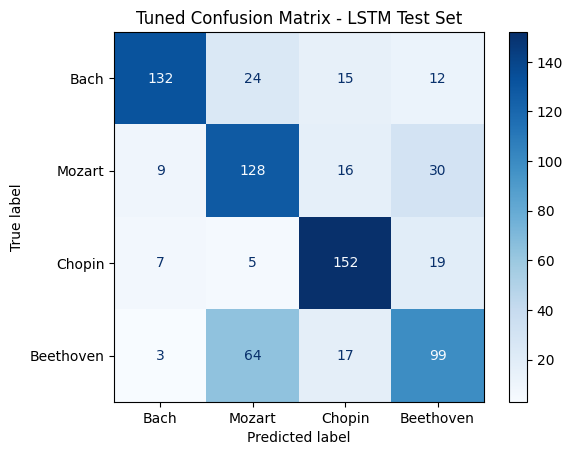

In [36]:
# Confusion matrix for tuned model
ConfusionMatrixDisplay(confusion_matrix(y_test, tuned_preds_lstm),
                       display_labels=composers).plot(cmap="Blues", values_format="d")
plt.title("Tuned Confusion Matrix - LSTM Test Set")
plt.show()

In [37]:
# Compare ROC AUC
print("Untuned LSTM ROC AUC Score:", round(roc_auc_score(y_test_cat, lstm.predict(X_test), multi_class="ovr"), 4))
print("Tuned LSTM ROC AUC Score:", round(roc_auc_score(y_test_cat, best_lstm_model.predict(X_test), multi_class="ovr"), 4))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Untuned LSTM ROC AUC Score: 0.8837
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Tuned LSTM ROC AUC Score: 0.8786


### 7.3 CNN Hyperparameter Tuning
* Tune number of convolutional blocks, values for convolutional blocks, dropout layer values, activation functions, number of dense layers, and initial learning rate
* Train new model with best hyperparameters

In [38]:
tf.keras.utils.set_random_seed(SEED)

# Method to tune CNN model
def build_tuning_cnn(hp):
  tf.keras.utils.set_random_seed(SEED)
  inputs = Input(shape=(MAX_LENGTH, n_features))

  # Hyperparameters for conv layers
  conv_filters_initial = hp.Choice('conv_filters_initial', values = [32, 64, 128])
  # Tune number of conv blocks
  num_conv_blocks = hp.Int('num_conv_blocks', min_value=1, max_value=3, default=3)
  # Tune dropout layer values
  dropout_val = hp.Choice('dropout', values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
  # Tune activation functions
  activation_choice = hp.Choice('activation', values = ['relu', 'leaky_relu', 'gelu']) # Added gelu

  x = inputs

  # Dynamically build Conv1D blocks
  for i in range(num_conv_blocks):
    # Scale filters for deeper layers, or cap if they grow too large
    current_filters = conv_filters_initial * (2**i)
    if current_filters > 512:
        current_filters = 512

    x = Conv1D(current_filters, 5, padding="same", activation=activation_choice)(x)
    # Apply max pooling and dropout to all but last conv block
    if i < num_conv_blocks - 1:
      x = MaxPooling1D(2)(x)
      x = Dropout(dropout_val)(x)

  x = GlobalMaxPooling1D()(x)

  # Tune number of dense layers
  num_dense_layers = hp.Int('num_dense_layers', min_value=1, max_value=2, default=1)
  for i in range(num_dense_layers):
    dense_neurons = hp.Choice(f'dense_neurons_{i}', values = [32, 64, 128, 256])
    x = Dense(dense_neurons, activation=activation_choice)(x)
    x = Dropout(dropout_val)(x)

  outputs = Dense(4, activation="softmax")(x)

  # Tune learning rate
  lr = hp.Choice('learning_rate', values = [1e-2, 5e-4, 1e-4, 1e-5])
  model = Model(inputs=inputs, outputs=outputs)
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                loss="categorical_crossentropy", metrics=["accuracy"])

  return model

# Define tuner
cnn_tuner = kt.RandomSearch(
    build_tuning_cnn,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=3,
    directory='tuning_results',
    project_name='tuning_cnn_v2'
)

# Run tuner
cnn_tuner.search(
    X_train, y_train_cat,
    epochs = 50,
    batch_size = 64,
    validation_data = (X_val, y_val_cat),
    callbacks = make_callbacks()
)

# Print out best hyperparameters
best_cnn_param = cnn_tuner.get_best_hyperparameters()[0].values
best_cnn_param

Trial 20 Complete [00h 00m 59s]
val_accuracy: 0.406862735748291

Best val_accuracy So Far: 0.6584967374801636
Total elapsed time: 00h 24m 03s


{'conv_filters_initial': 128,
 'num_conv_blocks': 3,
 'dropout': 0.1,
 'activation': 'relu',
 'num_dense_layers': 1,
 'dense_neurons_0': 64,
 'learning_rate': 0.0005,
 'dense_neurons_1': 256}

In [39]:
tf.keras.utils.set_random_seed(SEED)

# Tune new model with best hyperparameters
best_hp_cnn = cnn_tuner.get_best_hyperparameters(num_trials=1)[0]
cnn_tuned_model = build_tuning_cnn(best_hp_cnn)
cnn_tuned_model.fit(X_train, y_train_cat, epochs=40, batch_size=64, validation_data=(X_val, y_val_cat), callbacks=make_callbacks())

Epoch 1/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.4127 - loss: 1.2604 - val_accuracy: 0.3742 - val_loss: 1.2889 - learning_rate: 5.0000e-04
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5088 - loss: 1.1165 - val_accuracy: 0.4592 - val_loss: 1.1813 - learning_rate: 5.0000e-04
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5793 - loss: 1.0070 - val_accuracy: 0.4837 - val_loss: 1.1368 - learning_rate: 5.0000e-04
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6260 - loss: 0.9237 - val_accuracy: 0.4984 - val_loss: 1.0972 - learning_rate: 5.0000e-04
Epoch 5/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6663 - loss: 0.8397 - val_accuracy: 0.5229 - val_loss: 1.0608 - learning_rate: 5.0000e-04
Epoch 6/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7047 - loss: 0.7656 - val_accuracy: 0.5441 - val_loss: 1.0274 - learning_rate: 5.0000e-04
Epoch 7/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7250

In [40]:
# Classification report for tuned model
tuned_preds_cnn = np.argmax(cnn_tuned_model.predict(X_test), axis=1)
print(classification_report(y_test, tuned_preds_cnn, target_names=composers, digits=4))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
              precision    recall  f1-score   support

        Bach     0.7169    0.8579    0.7811       183
      Mozart     0.6257    0.5847    0.6045       183
      Chopin     0.8086    0.7158    0.7594       183
   Beethoven     0.5611    0.5519    0.5565       183

    accuracy                         0.6776       732
   macro avg     0.6781    0.6776    0.6754       732
weighted avg     0.6781    0.6776    0.6754       732



### 7.4 CNN Model Comparison
Compares results of untuned versus tuned model

In [41]:
# Compare classification report for untuned vs tuned
print(f"Untuned CNN: {classification_report(y_test, y_pred_cnn, target_names=composers, digits=4)}")
print(f"Tuned CNN: {classification_report(y_test, tuned_preds_cnn, target_names=composers, digits=4)}")

Untuned CNN:               precision    recall  f1-score   support

        Bach     0.6842    0.7814    0.7296       183
      Mozart     0.5708    0.7049    0.6308       183
      Chopin     0.8037    0.7158    0.7572       183
   Beethoven     0.6119    0.4481    0.5174       183

    accuracy                         0.6626       732
   macro avg     0.6677    0.6626    0.6587       732
weighted avg     0.6677    0.6626    0.6587       732

Tuned CNN:               precision    recall  f1-score   support

        Bach     0.7169    0.8579    0.7811       183
      Mozart     0.6257    0.5847    0.6045       183
      Chopin     0.8086    0.7158    0.7594       183
   Beethoven     0.5611    0.5519    0.5565       183

    accuracy                         0.6776       732
   macro avg     0.6781    0.6776    0.6754       732
weighted avg     0.6781    0.6776    0.6754       732



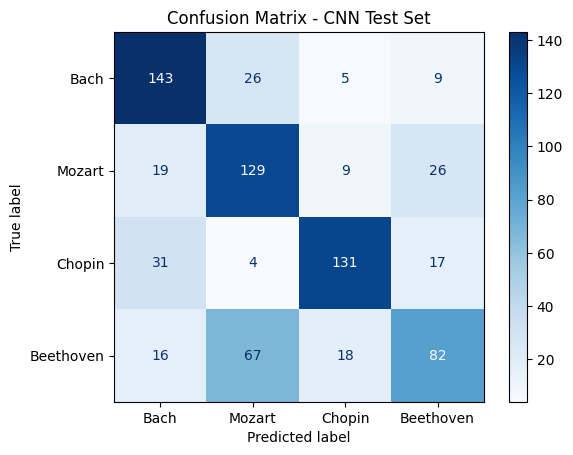

In [42]:
# Confusion matrix for untuned
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_cnn),
                       display_labels=composers).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - CNN Test Set")
plt.show()

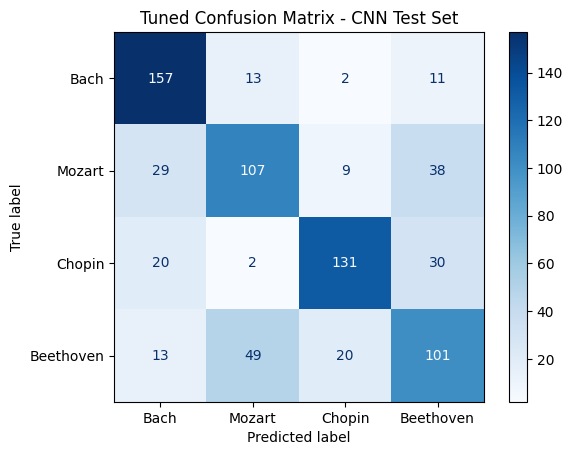

In [43]:
# Confusion matrix for tuned
ConfusionMatrixDisplay(confusion_matrix(y_test, tuned_preds_cnn),
                       display_labels=composers).plot(cmap="Blues", values_format="d")
plt.title("Tuned Confusion Matrix - CNN Test Set")
plt.show()

In [44]:
# Compare ROC AUC
print("Untuned CNN ROC AUC Score:", round(roc_auc_score(y_test_cat, cnn.predict(X_test), multi_class="ovr"), 4))
print("Tuned CNN ROC AUC Score:", round(roc_auc_score(y_test_cat, cnn_tuned_model.predict(X_test), multi_class="ovr"), 4))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Untuned CNN ROC AUC Score: 0.8718
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Tuned CNN ROC AUC Score: 0.8845


## 8. Conclusion

$\quad$ The results of this project are two sets of neural network models, trained to predict a composer from a list composed of Bach, Mozart, Chopin, or Beethoven, based on sheet music. The two sets of models are composed of one trained and one untrained version of either a CNN or LSTM model.


$\quad$ Through hyperparameter tuning using a Keras built in tuner, we were able to slightly improve the performance of both models. The LSTM hyperparameter tuning involved trying different units for the LSTM units, dropout values, activation function choices, dense neuron values, and learning rate. Each of these values were chosen from a list of possible options that the tuner was to filter through and determine which values created the highest accuracy. As a result, some evaluation metrics decreased, while others increased, but the overall accuracy slightly increased. For the different composers. Bach saw an increase in precision and F1 score, but a decrease in recall. Mozart saw a decrease in precision and F1, but an increase in recall. Chopin had an increase for all metrics, and Beethoven had decreases in all metrics. The overall accuracy for each model went from 0.689 to 0.698, however, indicating that the model performance very slightly increased.


$\quad$ The CNN model was harder to tune. We tuned factors such as the initial convolution filter value, the number of convolution blocks, the activation function used, the dropout value, the number of dense layers, dense neuron values, and the learning rate. As a result, the overall accuracy also slightly increased from 0.663 to 0.678. Compared to the untuned version, Bach had an increase in all metrics, Mozart dropped in recall and F1, Chopin saw very slight increases or stayed the same in all metrics, and Beethoven increased in all metrics except for recall.